In [1]:
import os
import emcee
import matplotlib.pyplot as plt

# Import the plotting function from your local module
from pdspl_utils.plotting import plot_dspl_corner

%load_ext autoreload
%autoreload 2

In [2]:
# --- 1. CONFIGURATION & TRUTH ---
truth = {
    'h0': 70.0, 'om': 0.3, 'w0': -1.0, 'wa': 0.0,
    'lambda_int': 1.0, 'lambda_sigma': 0.05,
    'gamma_pl': 2.0, 'gamma_sigma': 0.16
}

fixed_params = {'h0': 70.0}

latex_labels = {
    'om': r"$\Omega_{\rm m}$", 'w0': r"$w_0$", 'wa': r"$w_a$", 
    'lambda_int': r"$\overline{\lambda}_{\rm int}$", 
    'gamma_pl': r"$\overline{\gamma}_{\rm pl}$", 
    'gamma_sigma': r"$\sigma({\gamma}_{\rm pl})$", 
    'lambda_sigma': r"$\sigma({\lambda}_{\rm int})$"
}

custom_ranges = [
    (0, 1),            # om
    (-2, 0),           # w0
    (-3, 3),           # wa
    (truth['lambda_int'] - 0.1, truth['lambda_int'] + 0.1), # lambda_int
    (0.0, 0.10),       # lambda_sigma
    (truth['gamma_pl'] - 0.1, truth['gamma_pl'] + 0.1), # gamma_pl
    (0.12, 0.20),      # gamma_sigma
]

In [3]:
# --- 2. RECONSTRUCT SCENARIOS FROM .H5 FILES ---
POSTERIOR_DIRECTORY = '../data/posteriors/forecast_w0waCDM_fixed_scatter'

# Map the raw keys to the display names and colors from your original plot
scenario_metadata = {
    'lsst_4most_spec-z_sigma_v': {'name': 'PDSPL (4MOST ($z^{spec} + \\sigma_{v,D}$))', 'color': 'purple'},
    'lsst_4most_spec-z':         {'name': 'PDSPL (4MOST ($z^{spec}$))', 'color': 'red'},
    'DSPL':                      {'name': 'DSPL (500 lenses)', 'color': '#1f77b4'}, # Blue
    'lsst_y1':                   {'name': 'PDSPL (LSST Y1)', 'color': '#ff7f0e'},   # Orange
    'lsst_y10':                  {'name': 'PDSPL (LSST Y10)', 'color': '#2ca02c'}   # Green
}

reconstructed_scenarios = {}

print("Loading posteriors...")
for key, meta in scenario_metadata.items():
    file_path = os.path.join(POSTERIOR_DIRECTORY, f"{key}.h5")
    
    if os.path.exists(file_path):
        try:
            # Read the HDF5 backend
            reader = emcee.backends.HDFBackend(file_path)
            
            # Extract flattened chain. Assuming n_burn was 500 based on your previous code
            samples = reader.get_chain(discard=500, flat=True)
            
            # Rebuild the dictionary structure expected by your plotting function
            reconstructed_scenarios[key] = {
                'name': meta['name'],
                'color': meta['color'],
                'samples': samples
            }
            print(f"✅ Loaded {key}: {samples.shape[0]} samples")
        except Exception as e:
            print(f"❌ Failed to read {key}. Error: {e}")
    else:
        print(f"⚠️ File not found: {file_path}")

Loading posteriors...
✅ Loaded lsst_4most_spec-z_sigma_v: 96000 samples
✅ Loaded lsst_4most_spec-z: 96000 samples
✅ Loaded DSPL: 96000 samples
✅ Loaded lsst_y1: 96000 samples
✅ Loaded lsst_y10: 96000 samples


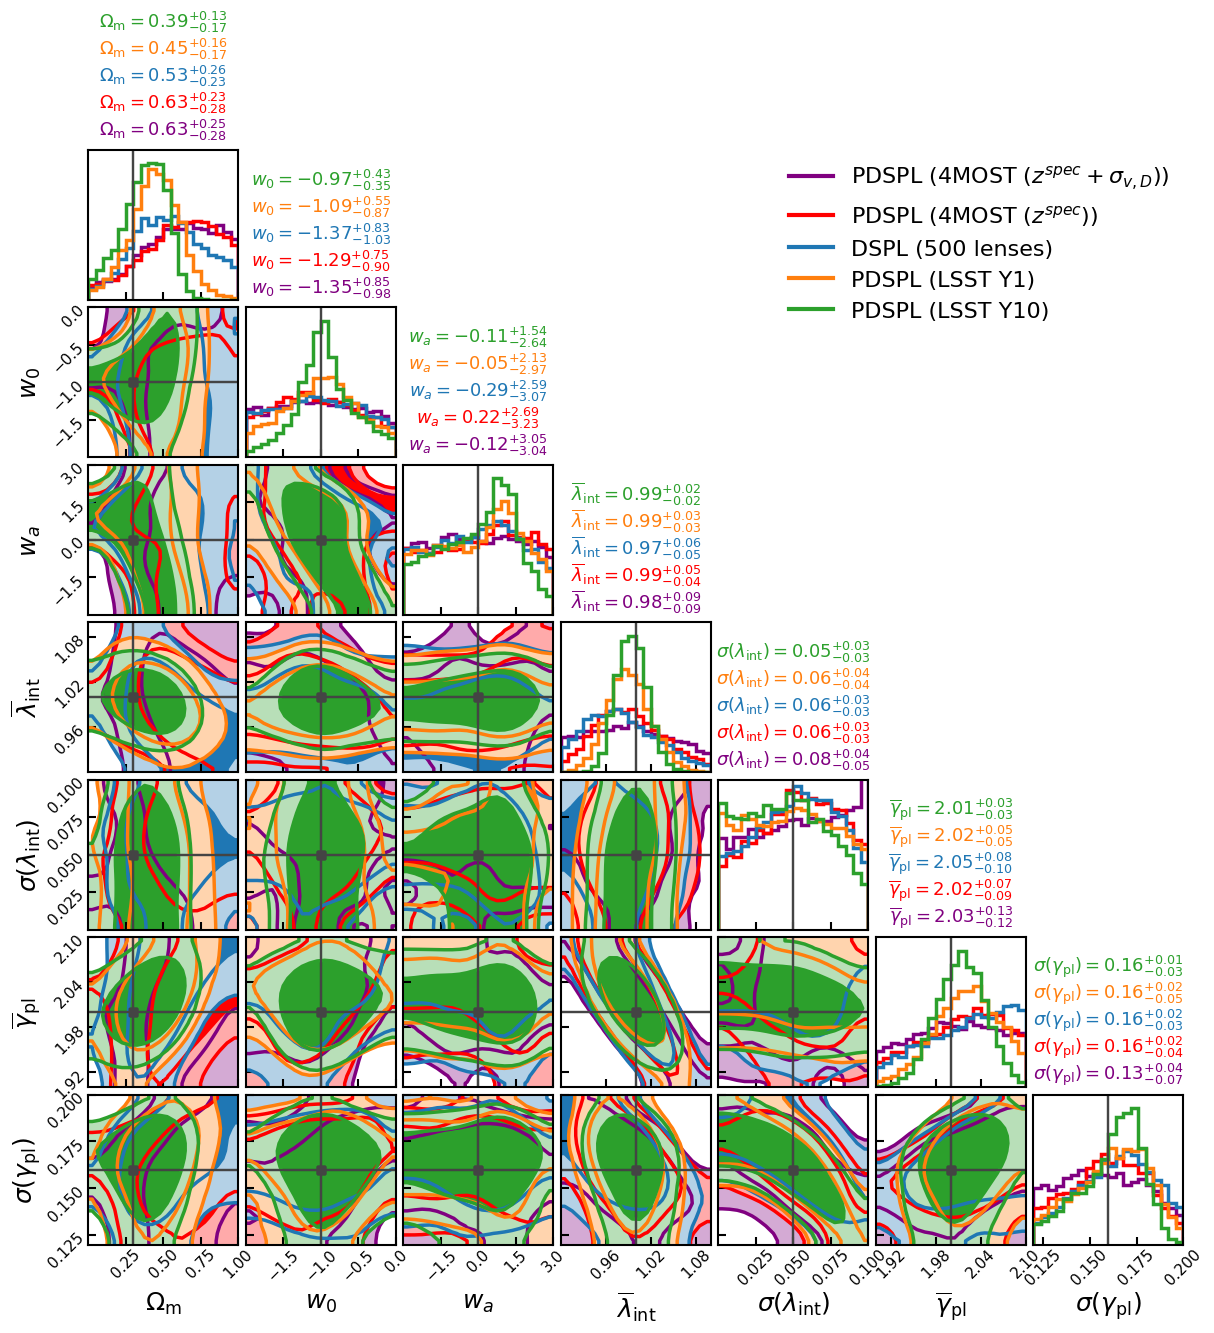

In [9]:
# --- 3. PLOT POSTERIORS ---
# Select the keys you want to plot (ensure they successfully loaded in the previous cell)
scenarios_to_plot = [
    'lsst_4most_spec-z_sigma_v', 
    'lsst_4most_spec-z', 
    'DSPL', 
    'lsst_y1', 
    'lsst_y10'
]

fig = plot_dspl_corner(
    scenarios=reconstructed_scenarios, 
    truth=truth, 
    fixed_params=fixed_params, 
    scenarios_to_plot=scenarios_to_plot, 
    custom_ranges=custom_ranges, 
    latex_labels=latex_labels, 
    figsize=(12, 12),
    show_multiple_titles=True
)

plt.show()